In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

import time
!pip install python-docx
from docx import Document
from docx.shared import Inches

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


In [ ]:
#Reading df_basic
df_name = 'df_basic_1.4' # standardized (will be introduced by standardScaler), resized (64,64) and grey

drive.mount('/content/drive')
df_basic = pd.read_pickle("/content/drive/My Drive/Team Project X-Rays/Dataframes/df_basic_1.4.pkl")
# Setting the image name as Index and display the first 5 lines
df_basic = df_basic.set_index('Name')
df_basic.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Case,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
Name,,,,,,,,,,,,,,,,,,,,,
COVID-3563,COVID,1,0,0,0,0,0,0,0,0,...,191,182,167,158,136,104,66,40,1,132
COVID-933,COVID,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
COVID-2646,COVID,61,15,6,4,3,3,3,3,4,...,235,234,234,230,224,216,213,209,210,204
COVID-3508,COVID,23,12,8,16,6,5,5,3,6,...,229,230,224,222,182,158,149,120,86,9
COVID-1165,COVID,101,110,100,27,26,24,34,37,25,...,203,215,214,212,209,204,192,184,184,171


In [ ]:
# Encode classes as numbers (LabelEncoder)
le = LabelEncoder()
df_basic['Case'] = le.fit_transform(df_basic['Case'])

# Splitting data into features (X) and target (y)
X = df_basic.drop('Case', axis=1)
y = df_basic['Case']

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)


In [ ]:
# Standardise the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**PCA (Principal component analysis)**

In [ ]:
### --- PCA (Principal component analysis) --- ###

# Instantiating a PCA object (It shall generate as many components that are needed in order to explain 90 % of the datas variability)
pca = PCA(n_components = 0.9)

# Fit and transform the data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


The number of components needed to explain 90 % of the datas variability are: 62
The first two components explain 39.0 % of the variability.


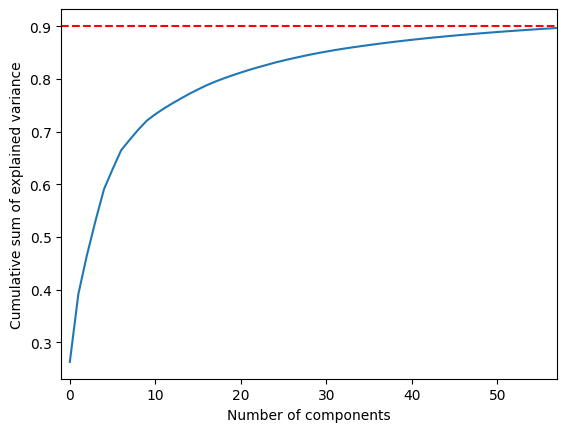

In [ ]:
# Report of how many dimensions are necessary to keep the majority of the informational content
print(f'The number of components needed to explain 90 % of the datas variability are: {pca.n_components_}')
print(f"The first two components explain {round(pca.explained_variance_ratio_[0:2].sum(),2)*100} % of the variability.")

# Plot the cumulative sum of the explained variance
plt.figure()
plt.xlim(-1, 57)
plt.xlabel('Number of components')
plt.ylabel('Cumulative sum of explained variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.plot(pca.explained_variance_ratio_.cumsum());

# Save image as .png
plt.savefig(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png', bbox_inches = 'tight')


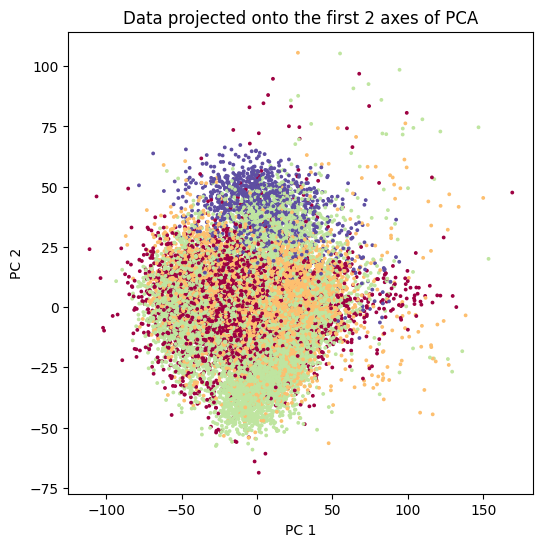

In [ ]:
# Plot the observations using the first two components of the PCA
plt.figure(figsize = (6,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c = y_train, s = 3, cmap=plt.cm.Spectral);
plt.xlabel('PC 1')
plt.ylabel('PC 2')

plt.title("Data projected onto the first 2 axes of PCA")

# Save image as .png
plt.savefig(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png', bbox_inches = 'tight')


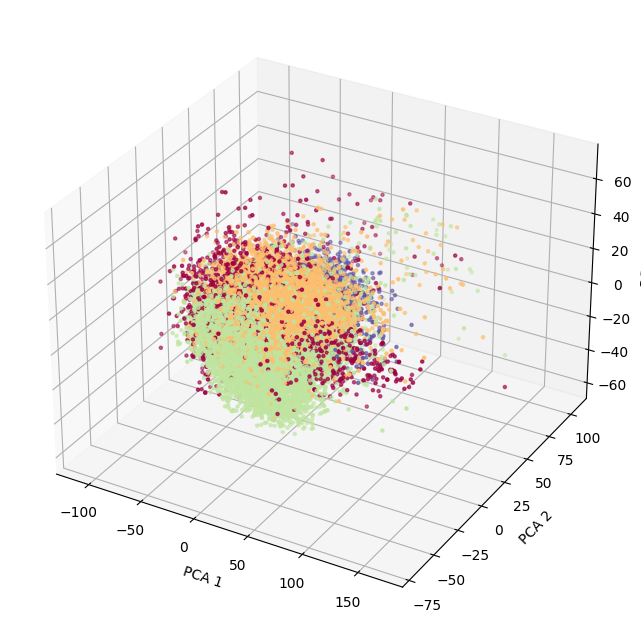

In [ ]:
# 3D plot of the first 3 principle components
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train_pca[:,0], X_train_pca[:,1], X_train_pca[:,2], c = y_train, s = 5, cmap=plt.cm.Spectral)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

# Save image as .png
plt.savefig(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png', bbox_inches = 'tight')

# Again the 4 classes are not well separated


,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
PC1,-0.001748,-0.003451,-0.003918,-0.003897,-0.003977,-0.004038,-0.004074,-0.004070,-0.004041,-0.004180,...,-0.013207,-0.013028,-0.012723,-0.012238,-0.011576,-0.010798,-0.010041,-0.009137,-0.008312,-0.006789
PC2,0.001329,0.007679,0.010423,0.011908,0.012845,0.013973,0.014923,0.015681,0.016159,0.016496,...,-0.011061,-0.010544,-0.010341,-0.010280,-0.010679,-0.010967,-0.010737,-0.009614,-0.008339,-0.008930
PC3,-0.013902,-0.012151,-0.012158,-0.013015,-0.013539,-0.013822,-0.013932,-0.014205,-0.014279,-0.014248,...,-0.001179,0.000058,0.001518,0.003206,0.005203,0.007237,0.008951,0.010302,0.010333,0.007491
PC4,-0.002266,0.001334,0.000936,0.000202,-0.000282,-0.000917,-0.001618,-0.002112,-0.002661,-0.002800,...,-0.004871,-0.002805,-0.000235,0.002385,0.005160,0.007858,0.010306,0.012311,0.013869,0.012603
PC5,0.000210,0.001346,0.000586,-0.000287,-0.000984,-0.001421,-0.001831,-0.002158,-0.002185,-0.002158,...,0.019448,0.022740,0.025726,0.028211,0.029958,0.030754,0.030402,0.029122,0.026952,0.022031


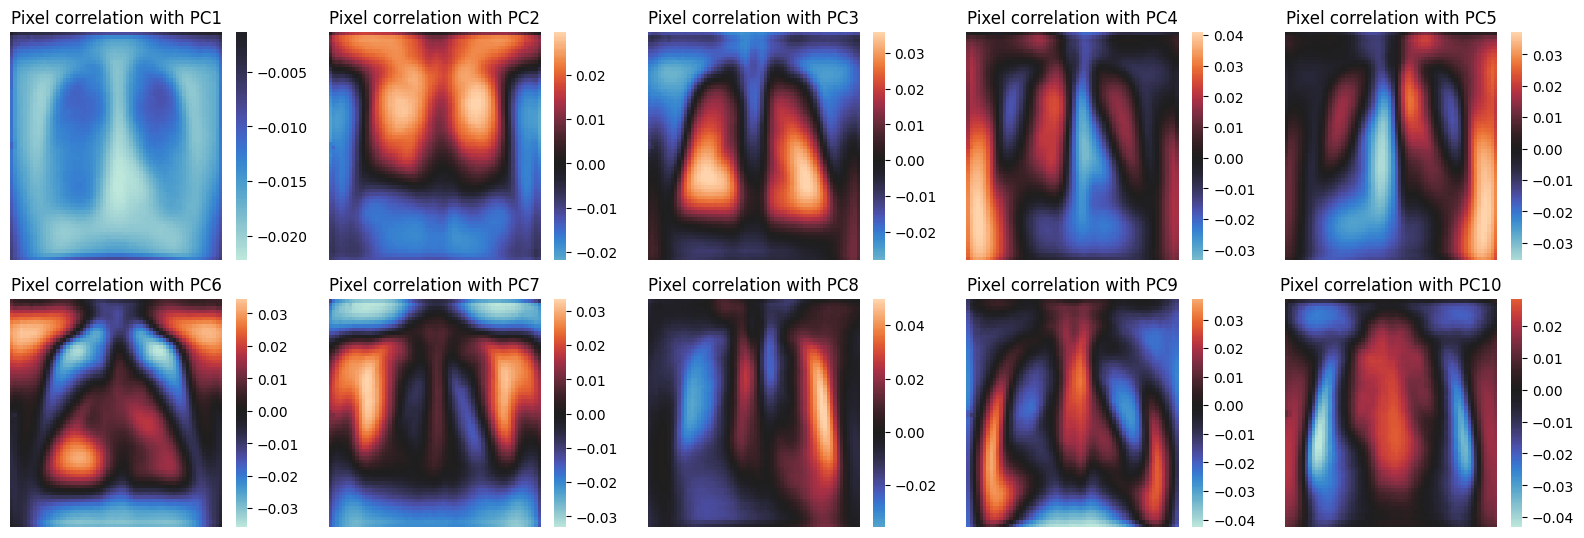

In [ ]:
### --- Interpretation of PCA (which parts of the images are important) --- ###

# Get the correlations of each pixel to the 57 PCs and create a dataframe with this information (rows = PCs, columns = PXs)
corr_df = pd.DataFrame(pca.components_[0:pca.components_.shape[0]+1,:], columns= X.columns, index = [f'PC{i+1}' for i in range(pca.components_.shape[0])])
display(corr_df.head())

# Convert rows of corr_df to a image-shaped numpy array (64,64)
def row_to_image_array (df, number_PCA):
  # Convert row to a numpy array
  row_as_array = corr_df.iloc[number_PCA].values
  # Reshape the numpy array to our current image size (64x64)
  reshaped_array = np.reshape(row_as_array, (64, 64))
  return reshaped_array

# Plotting the correlation of each pixel with the first 10 PCs as an image shaped heat-map in a 2x5 raster
# Define colormap
sns.color_palette("icefire", as_cmap=True)
# Create the subplot grid
fig, axes = plt.subplots(2, 5, figsize=(16, 5.5))

for i in np.arange(0,10):
    # Generate the reshaped array for row i
    reshaped_array = row_to_image_array(corr_df, i)
    # Define position in the subplot grid
    ax = axes[i // 5, i % 5]
    # Plot the heatmap
    sns.heatmap(reshaped_array, ax=ax,  center=0, cmap='icefire')
    ax.set_title(f'Pixel correlation with PC{i+1}')
    ax.axis('off')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png', bbox_inches = 'tight')


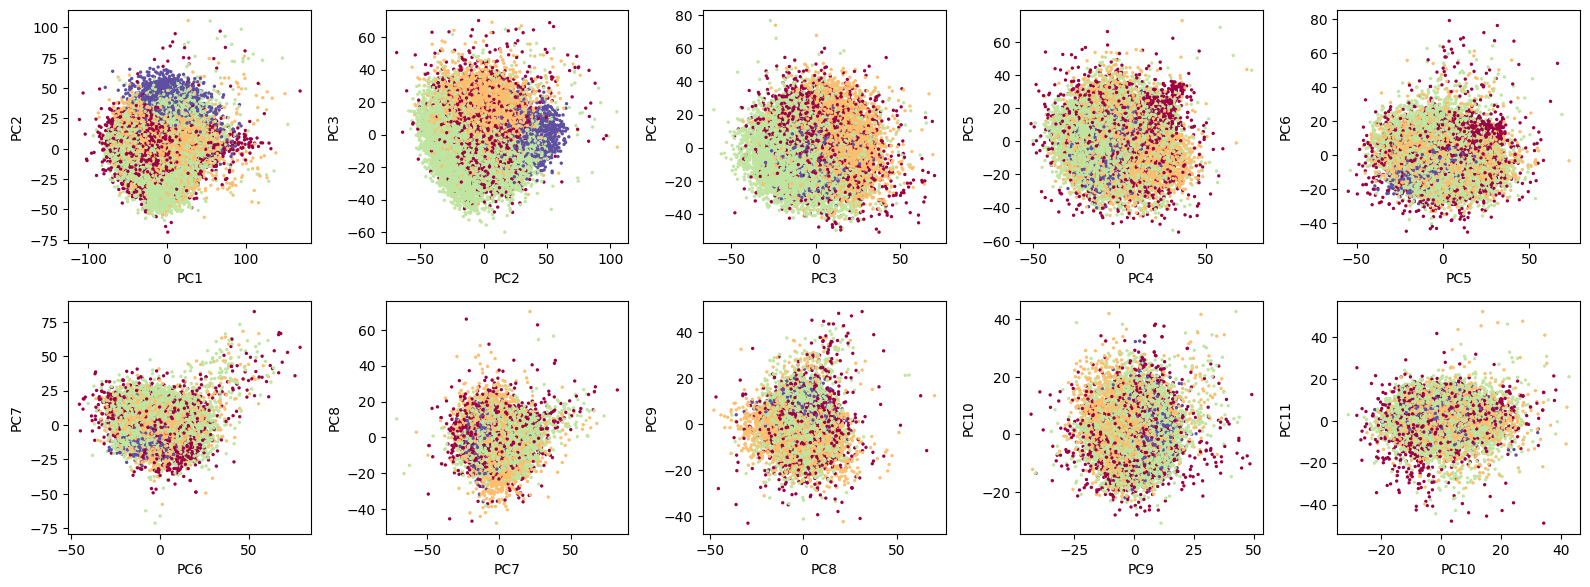

In [ ]:
# Plot the observations projected onto the different PC axes in decreasing order/importance
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for i in np.arange(0,10):
    ax = axes[i // 5, i % 5]
    ax.scatter(X_train_pca[:, i], X_train_pca[:, i+1], c=y_train, s=2, cmap=plt.cm.Spectral);
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{i+2}')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png', bbox_inches = 'tight')


**LDA (Linear discriminant analysis)**

In [ ]:
### --- LDA (Linear discriminant analysis) --- ###

lda = LDA()
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)


In [ ]:
# Print the shape
X_train_lda.shape


(16884, 3)

Train score: 0.8594527363184079
Test score: 0.6853826107557451


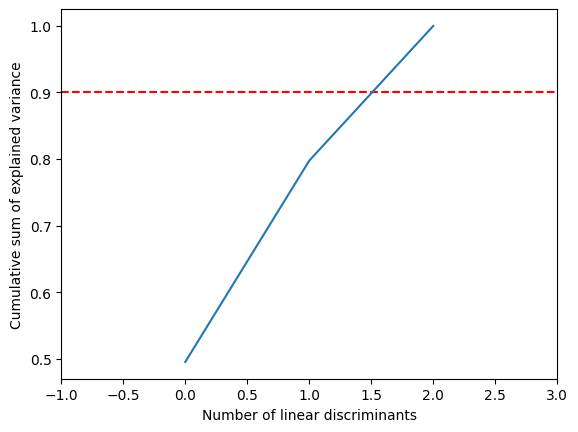

In [ ]:
# Plot the cumulative sum of the explained variance
plt.figure()
plt.xlim(-1, 3)
plt.xlabel('Number of linear discriminants')
plt.ylabel('Cumulative sum of explained variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.plot(lda.explained_variance_ratio_.cumsum())

# Save image as .png
plt.savefig(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png', bbox_inches = 'tight')

# Assess the score of 'LDA classification'
print(f'Train score: {lda.score(X_train, y_train)}')
print(f'Test score: {lda.score(X_test, y_test)}')

The first two components explain 79.80000000000001 % of the variability.


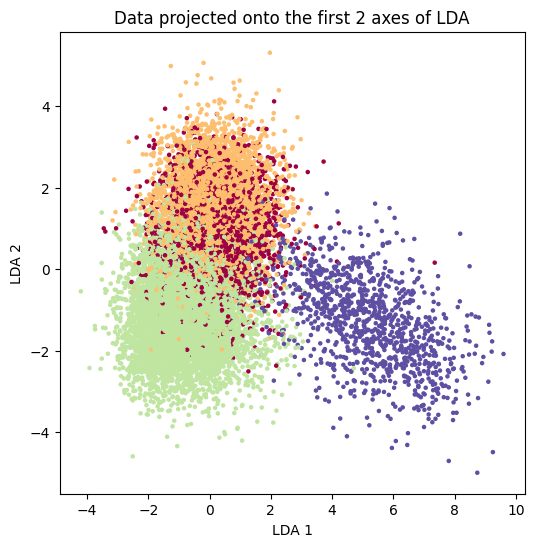

In [ ]:
# Report the explained variance for the first two components
print(f"The first two components explain {round(lda.explained_variance_ratio_[0:2].sum(),3)*100} % of the variability.")

# Plot the observations using the first two components of the LDA
plt.figure(figsize = (6,6))
plt.scatter(X_train_lda[:,0], X_train_lda [:,1], c = y_train, s = 5, cmap=plt.cm.Spectral);
plt.xlabel('LDA 1')
plt.ylabel('LDA 2')

plt.title("Data projected onto the first 2 axes of LDA")

# Save image as .png
plt.savefig(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png', bbox_inches = 'tight')


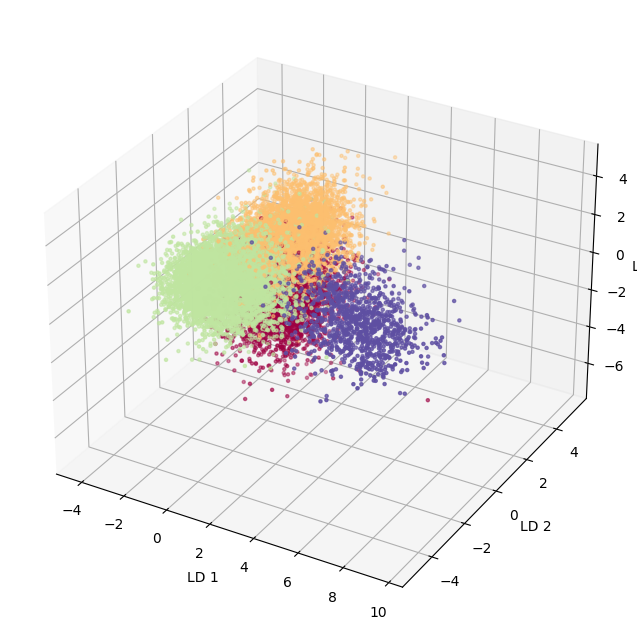

In [ ]:
# 3D plot of all 3 linear discriminants
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train_lda[:,0], X_train_lda[:,1], X_train_lda[:,2], c = y_train, s = 5, cmap=plt.cm.Spectral)
ax.set_xlabel('LD 1')
ax.set_ylabel('LD 2')
ax.set_zlabel('LD 3')

# Save image as .png
plt.savefig(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png', bbox_inches = 'tight')


,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
PC1,-0.051509,-0.203047,-0.033333,-0.110310,-0.420931,0.783780,-0.894424,0.031880,0.396624,0.367640,...,-0.028328,-0.078791,0.324480,-0.363762,0.149978,-0.048671,0.018376,0.210475,-1.207297,1.705474
PC2,0.045134,0.405540,-0.126182,-0.185627,0.185404,0.174566,0.011555,-0.016445,-0.267009,0.045101,...,0.156058,-0.352205,0.342401,-0.246319,0.082365,0.267556,-0.337174,0.110606,-0.042998,0.024803
PC3,-0.081151,0.017423,-0.138935,0.135004,0.212844,-0.107930,0.081056,-0.127461,0.058706,-0.195717,...,0.083271,0.017314,-0.124444,-0.053753,-0.076920,-0.132649,0.400735,-0.160692,0.489992,-0.446006
PC4,0.550463,-1.376940,1.692239,0.091824,-1.303075,-2.037501,1.715038,0.949270,-0.321761,0.300819,...,-1.239902,1.629224,-1.430890,2.456735,-0.180913,-0.047666,-1.587885,0.165977,-0.298352,-1.277572


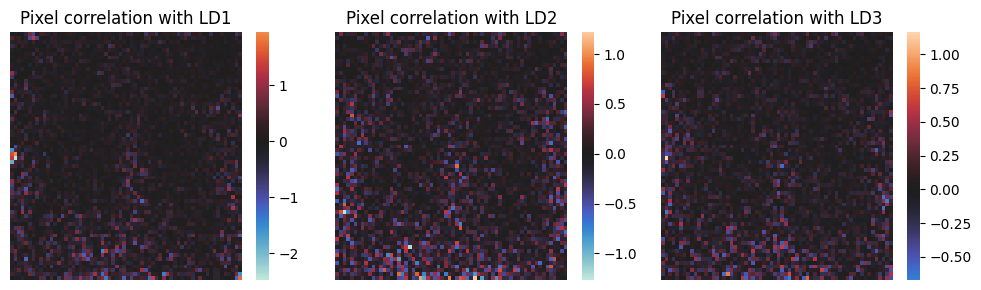

In [ ]:
### --- Interpretation of LDA (which parts of the images are important) --- ###

# Get the correlations of each pixel to the 3 PCs and create a dataframe with this information (rows = LDs, columns = PXs)
corr_df = pd.DataFrame(lda.coef_[0:lda.coef_.shape[0]+1,:], columns= X.columns, index = [f'PC{i+1}' for i in range(lda.coef_.shape[0])])
display(corr_df.head())

# Convert rows of corr_df to a image-shaped numpy array (64,64)
def row_to_image_array (df, number_LDA):
  # Convert row to a numpy array
  row_as_array = corr_df.iloc[number_LDA].values
  # Reshape the numpy array to our current image size (64x64)
  reshaped_array = np.reshape(row_as_array, (64, 64))
  return reshaped_array

# Plotting the correlation of each pixel with the first 10 PCs as an image shaped heat-map in a 2x5 raster
# Define colormap
sns.color_palette("icefire", as_cmap=True)
# Create the subplot grid
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i in np.arange(0,3):
    # Generate the reshaped array for row i
    reshaped_array = row_to_image_array(corr_df, i)
    # Define position in the subplot grid
    ax = axes[i]
    # Plot the heatmap
    sns.heatmap(reshaped_array, ax=ax,  center=0, cmap='icefire')
    ax.set_title(f'Pixel correlation with LD{i+1}')
    ax.axis('off')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png', bbox_inches = 'tight')


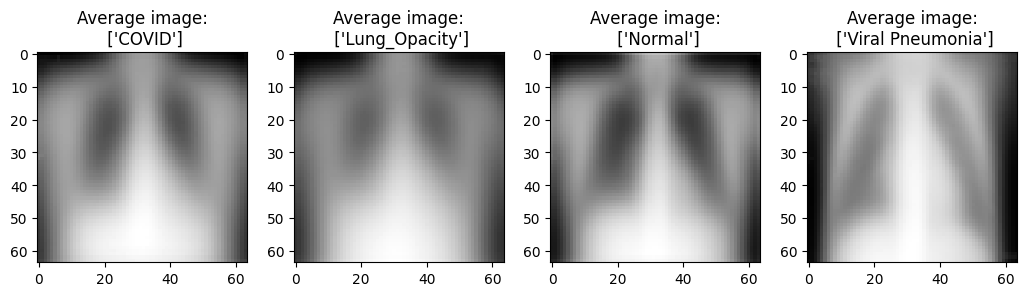

In [ ]:
# Generating and displaying the average image of each class
X_array = X.to_numpy()
y_array = y.to_numpy()

plt.figure(figsize = (16,6))
for i in np.arange(0,4):
    indices = np.where(y==i)[0]
    average_image = X_array[indices].mean(axis=0)
    reshaped_average_image = np.reshape(average_image, (64, 64))
    plt.subplot(2,5, i+1)
    plt.imshow(reshaped_average_image, cmap='gray')
    plt.title(f'Average image:\n {le.inverse_transform([i])}')

# Save image as .png
plt.savefig(f'/content/Average image of each class_{df_name}.png', bbox_inches = 'tight')


In [ ]:
# Generate random data for test purposes
np.random.seed(0)  # For reproducibility
data = np.random.randn(100, 9)  # 9 feature columns

# Create target column with integers 1-4
target = np.random.randint(1, 5, size=(100, 1))

# Concatenate target and feature columns
data = np.hstack((target, data))

# Create a DataFrame
df = pd.DataFrame(data, columns=['target'] + [f'feature_{i}' for i in range(9)])
display(df.head())

# Encode classes as numbers (LabelEncoder)
lenc = LabelEncoder()
df['target'] = lenc.fit_transform(df['target'])

data = df.drop('target', axis=1)
target = df['target']

# Splitting data into training and testing sets
X_train__check, X_test__check, y_train_check, y_test_check = train_test_split(data, target, test_size=0.2)


,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8
0,3.0,1.764052,0.400157,0.978738,2.240893,1.867558,-0.977278,0.950088,-0.151357,-0.103219
1,4.0,0.410599,0.144044,1.454274,0.761038,0.121675,0.443863,0.333674,1.494079,-0.205158
2,2.0,0.313068,-0.854096,-2.552990,0.653619,0.864436,-0.742165,2.269755,-1.454366,0.045759
3,2.0,-0.187184,1.532779,1.469359,0.154947,0.378163,-0.887786,-1.980796,-0.347912,0.156349
4,3.0,1.230291,1.202380,-0.387327,-0.302303,-1.048553,-1.420018,-1.706270,1.950775,-0.509652


In [ ]:
### --- Test predictive performance with different techniques of dimension reduction applied to the data set --- ###

# Setting up four different models
lr = LogisticRegression(solver='lbfgs', C = 1.0, max_iter=10000)
knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski')
svc = SVC(gamma = 0.01, kernel = "poly")
dt = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=123)

# Define function to test model performance
def test_performance(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    cl_report = classification_report(y_te, model.predict(X_te), output_dict=True)
    cl_report_df = pd.DataFrame(cl_report).transpose()
    f1_scores_covid = cl_report_df.iloc[le.transform(['COVID'])[0]]['f1-score']
    f1_score_opacity = cl_report_df.iloc[le.transform(['Lung_Opacity'])[0]]['f1-score']
    f1_score_normal = cl_report_df.iloc[le.transform(['Normal'])[0]]['f1-score']
    f1_score_pneumonia = cl_report_df.iloc[le.transform(['Viral Pneumonia'])[0]]['f1-score']
    return model.score(X_train, y_train), model.score(X_test, y_test), f1_scores_covid, f1_score_opacity, f1_score_normal, f1_score_pneumonia


# Create list of data sets to be analysed
datasets = [
    (X_train, X_test, y_train, y_test, 'No dimension reduction'),
    (X_train_pca, X_test_pca, y_train, y_test, 'PCA'),
    (X_train_lda, X_test_lda, y_train, y_test, 'LDA'),
    #(X_train__check, X_test__check, y_train_check, y_test_check, 'check')
    ]

# Create list of models to be tested
models = [
    (lr, 'LogisticRegression'),
     (knn, 'KNeighbors'),
      (svc, 'SVC'),
       (dt, 'DecisionTree')
       ]

# Create empty lists to store results
model_names =[]
dataset_names = []
model_scores = []
execution_times = []

# Loop through the different models and data sets to determine the
# performance of each model on each test set
for model, model_name in models:
  for X_tr, X_te, y_tr, y_te, dataset_name in datasets:
    # Add model name to list
    model_names.append(model_name)
    # Add dataset name to the list
    dataset_names.append(dataset_name)
    # Record the start time
    start_time = time.time()
    # Fit model and calculate train and test score
    model_scores.append(test_performance(X_tr, X_te, y_tr, y_te,model))
    # Record the end time
    end_time = time.time()
    # Calculate the execution time
    execution_time = (end_time - start_time)/60
    # Add execution time to the list
    execution_times.append(execution_time)

# Create a DataFrame with the results and display it
results = pd.DataFrame({'Model': model_names, 'Dataset': dataset_names, 'Train_accuracy': np.array(model_scores)[:,0], 'Test_accuracy': np.array(model_scores)[:,1], 'f1_covid' : np.array(model_scores)[:,2],
                        'f1_lung_opacity' : np.array(model_scores)[:,3], 'f1_normal' : np.array(model_scores)[:,4], 'f1_pneumonia' : np.array(model_scores)[:,5], 'f1_mean' : np.array(model_scores)[:,2:6].mean(axis=1), 'Execution time [min]': execution_times})
display(results)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels wit

,Model,Dataset,Train_accuracy,Test_accuracy,f1_covid,f1_lung_opacity,f1_normal,f1_pneumonia,f1_mean,Execution time [min]
0,LogisticRegression,No dimension reduction,0.972755,0.630419,0.468223,0.574225,0.707019,0.798450,0.636979,81.321182
1,LogisticRegression,PCA,0.721393,0.726842,0.448908,0.700896,0.800000,0.851782,0.700397,0.109336
2,LogisticRegression,LDA,0.860637,0.683724,0.512035,0.639700,0.760885,0.725979,0.659650,0.002252
3,KNeighbors,No dimension reduction,0.828121,0.788676,0.667186,0.736338,0.845091,0.891841,0.785114,2.053869
4,KNeighbors,PCA,0.843757,0.809050,0.690590,0.764419,0.860658,0.889780,0.801362,0.070839
5,KNeighbors,LDA,0.875444,0.673300,0.495091,0.632280,0.753509,0.722323,0.650801,0.023380
6,SVC,No dimension reduction,1.000000,0.797678,0.688248,0.763945,0.842889,0.907336,0.800604,22.916337
7,SVC,PCA,1.000000,0.803838,0.723024,0.761711,0.845099,0.910134,0.809992,1.398180
8,SVC,LDA,0.610578,0.563847,0.238733,0.220386,0.685894,0.714286,0.464825,0.287329
9,DecisionTree,No dimension reduction,0.640014,0.625207,0.443497,0.545073,0.742630,0.478723,0.552481,0.340677


In [ ]:
# Save the DataFrame as a CSV file
results.to_excel(f'/content/Model performance before and after dimension reduction_{df_name}.xlsx', index=False)


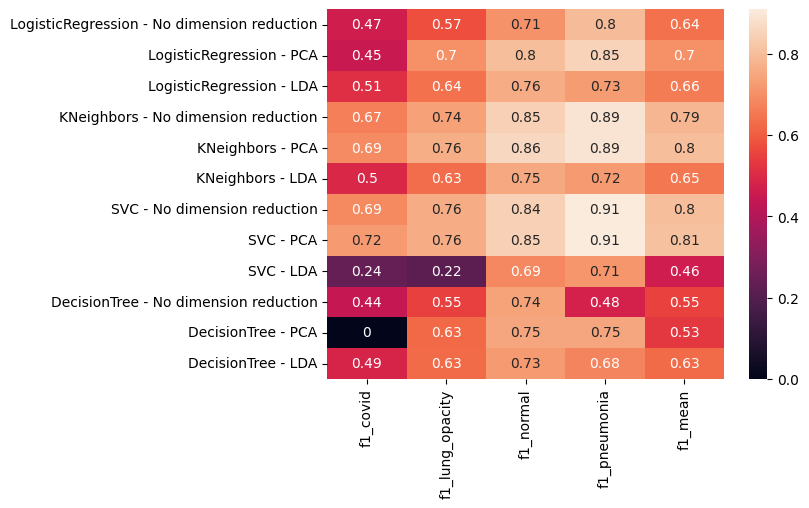

In [ ]:
# Create a heatmap for visual interpretation
orange_pallet = sns.color_palette("YlOrBr", as_cmap=True)
sns.heatmap(results[['f1_covid', 'f1_lung_opacity', 'f1_normal', 'f1_pneumonia', 'f1_mean']], yticklabels= results['Model']+' - '+results['Dataset'], annot = True)#, cmap = 'dark:salmon_r')

# Save image as .png
plt.savefig(f'/content/Heatmap_model_performance_{df_name}.png', bbox_inches = 'tight')


In [ ]:
# Insert grafics in word-docx
# Create a word document
doc = Document()

# Create a heading
doc.add_heading(f'The impact of dimension reduction - Images for the analysis of {df_name}', 0)

# Add graphs to the document
doc.add_picture(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png')
doc.add_picture(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png')
doc.add_picture(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png')
doc.add_picture(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png')
doc.add_picture(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png')
doc.add_picture(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png')
doc.add_picture(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png')
doc.add_picture(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png')
doc.add_picture(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png')
doc.add_picture(f'/content/Average image of each class_{df_name}.png')
doc.add_picture(f'/content/Heatmap_model_performance_{df_name}.png')

# Save word document
doc.save(f'The impact of dimension reduction - Images for the analysis of {df_name}.docx')



In [ ]:
# Downloads
files.download(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png')
files.download(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png')
files.download(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png')
files.download(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png')
files.download(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png')
files.download(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png')
files.download(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png')
files.download(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png')
files.download(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png')
files.download(f'/content/Average image of each class_{df_name}.png')
files.download(f'/content/Model performance before and after dimension reduction_{df_name}.xlsx')
files.download(f'/content/Heatmap_model_performance_{df_name}.png')
files.download(f'The impact of dimension reduction - Images for the analysis of {df_name}.docx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>